# Climb Fuel Prediction using XGBoost

Goal:
Predict fuel consumption during the climb phase using ADS-B derived flight phase features.

### Imports

In [1]:
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.metrics import mean_absolute_error,  mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


### Load feature dataset

The climb-phase feature table is loaded from the SQLite database.
Each row represents one flight with aggregated phase-level features.

Target variable:
- climb_fuel

Input features:
- `alt_gain_m_climb`: altitude gained during climb
- `time_s_climb`: climb duration
- `dist_m_climb`: distance flown during climb
- `alt_loss_m_climb`: altitude lost during climb
- `mean_alt_m_climb`: mean altitude during climb
- `max_alt_m_climb`: maximum altitude during climb
- `mean_vr_mps_climb`: mean vertical rate during climb
- `mean_gs_mps_climb`: mean ground speed during climb
- `p95_gs_mps_climb`: 95th percentile ground speed during climb
- `std_gs_mps_climb`: ground speed variability during climb
- `p95_abs_vr_mps_climb`: 95th percentile absolute vertical rate during climb
- `turn_sum_deg_climb`: cumulative heading change during climb
- `great_circle_distance`: route distance between departure and arrival airports
- `n_points_climb`: number of ADS-B observations assigned to climb

These ADS-B derived features describe the climb-phase trajectory, altitude profile, speed profile, vertical motion, turning behavior, route length, and observation coverage.

In [ ]:
DB_PATH = "../../data.sqlite"
FEATURE_TABLE = "flight_phase_features"

YEAR = 2022

TARGET = "climb_fuel"

FEATURES = [
    "alt_gain_m_climb",
    "time_s_climb",
    "dist_m_climb",
    "alt_loss_m_climb",
    "mean_alt_m_climb",
    "max_alt_m_climb",
    "mean_vr_mps_climb",
    "mean_gs_mps_climb",
    "p95_gs_mps_climb",
    "std_gs_mps_climb",
    "p95_abs_vr_mps_climb",
    "turn_sum_deg_climb",
    "great_circle_distance",
    "n_points_climb"

]


### Reconstruct Flight Datetime

The dataset does not contain an explicit `flight_dt` column.
Instead, the flight timestamp is reconstructed from the `flight_id`,
which follows the format:

    icao24-callsign-mm-dd-hh-mm

The flight date and time are parsed and converted into a proper datetime object (`flight_dt`).
This timestamp is later used for the temporal train/test split, helping avoid leakage from future flights into model training.

We also define a custom MAPE helper and a `make_X` helper for preparing model inputs.


In [3]:
def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    if parts.shape[1] < 6:
        raise ValueError("flight_id must be: icao24-callsign-mm-dd-hh-mm")

    month  = parts[2].astype(int)
    day    = parts[3].astype(int)
    hour   = parts[4].astype(int)
    minute = parts[5].astype(int)

    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100

def make_X(dfx: pd.DataFrame) -> pd.DataFrame:
    return dfx[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)

### Load feature table from SQLite

In [4]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month

print("Rows total:", len(df))


Rows total: 14015


### Filter Valid Climb Observations

We restrict the dataset to flights with:

- Non-missing climb fuel (`climb_fuel`)
- Positive climb duration
- Positive altitude gain during climb

This ensures that the model is trained only on meaningful climb-phase observations.

In [5]:
missing_feats = [c for c in FEATURES if c not in df.columns]
if missing_feats:
    raise ValueError(f"Missing required feature columns: {missing_feats}")

df2 = df[df[TARGET].notna()].copy()
df2 = df2[df2["time_s_climb"].fillna(0.0) > 0.0].copy()
df2 = df2[df2["alt_gain_m_climb"].fillna(0.0) > 0.0].copy()

df2["month"] = df2["flight_dt"].dt.month

print("Filtered rows:", len(df2))

Filtered rows: 14014


### Temporal Data Split

We split the dataset into:

- Development period: January–October  
- Test period: November–December  

The development period is used for time-based cross-validation and hyperparameter selection.

The test period remains completely unseen until final evaluation to ensure an unbiased estimate of model performance.

In [6]:
dev = df2[df2["month"] <= 10].copy()   # Jan-Oct
test = df2[df2["month"] >= 11].copy()  # Nov-Dec, valid climb rows for model evaluation
test_all = df[df["month"] >= 11].copy()  # Nov-Dec, all flights for total-fuel export

print("Development:", len(dev), "| Test:", len(test), "| Test all:", len(test_all))


Development: 10509 | Test: 3505 | Test all: 3505


### Expanding-Window Cross-Validation with Early Stopping

The January-October development data are sorted by departure time and split using `TimeSeriesSplit`.

For each split, the model is trained on earlier flights and validated on the next time period. The training window expands for each split, so the model is always evaluated on future data.

A random search with 50 trials is used to tune the XGBoost hyperparameters. For each trial, the last 20% of the training window is used for early stopping. Training stops if the validation MAE does not improve for 200 boosting rounds.

The hyperparameter combination with the lowest mean validation MAE is selected. The November-December test set is kept separate and used only for final evaluation.


In [7]:
df_cv = dev.sort_values("flight_dt").reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

param_space = {
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [0.5, 1, 2, 5],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "gamma": [0, 0.1, 0.5, 1],
}

N_TRIALS = 50

param_list = list(ParameterSampler(
    param_space,
    n_iter=N_TRIALS,
    random_state=42
))

results = []

for trial, params in enumerate(param_list, start=1):
    fold_mae = []
    fold_rmse = []
    fold_mape = []
    fold_r2 = []
    best_iters = []

    for train_idx, val_idx in tscv.split(df_cv):
        train_fold = df_cv.iloc[train_idx].copy()
        val_fold = df_cv.iloc[val_idx].copy()

        split = int(len(train_fold) * 0.8)
        tr = train_fold.iloc[:split]
        es = train_fold.iloc[split:]

        X_tr = make_X(tr)
        y_tr = tr[TARGET].to_numpy()

        X_es = make_X(es)
        y_es = es[TARGET].to_numpy()

        X_val = make_X(val_fold)
        y_val = val_fold[TARGET].to_numpy()

        model = XGBRegressor(
            n_estimators=12000,
            objective="reg:gamma",
            eval_metric="mae",
            early_stopping_rounds=200,
            random_state=42,
            n_jobs=-1,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_es, y_es)],
            verbose=False
        )

        pred = model.predict(X_val)

        fold_mae.append(mean_absolute_error(y_val, pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
        fold_mape.append(mape(y_val, pred))
        fold_r2.append(r2_score(y_val, pred))
        best_iters.append(model.best_iteration)

    results.append({
        **params,
        "mean_mae": np.mean(fold_mae),
        "std_mae": np.std(fold_mae),
        "mean_rmse": np.mean(fold_rmse),
        "mean_mape": np.mean(fold_mape),
        "mean_r2": np.mean(fold_r2),
        "avg_best_iter": int(np.mean(best_iters)),
    })

results_df = pd.DataFrame(results).sort_values("mean_mae")
best_row = results_df.iloc[0]

#print(best_row)


### Final Model Training and Evaluation

After cross-validation, the selected hyperparameters and the average best number of boosting rounds are extracted from the best-performing trial.

The final model is trained on the full January-October development set using the selected hyperparameters and fixed number of estimators. No early stopping is used at this stage, since the number of boosting rounds has already been selected during cross-validation.

The final model is then evaluated on the November-December test set, which was not used during cross-validation or hyperparameter tuning.

Performance is evaluated using MAE, RMSE, MAPE, and $R^2$.


In [8]:
best_params = {
    "learning_rate": best_row["learning_rate"],
    "max_depth": int(best_row["max_depth"]),
    "min_child_weight": best_row["min_child_weight"],
    "subsample": best_row["subsample"],
    "colsample_bytree": best_row["colsample_bytree"],
    "reg_lambda": best_row["reg_lambda"],
    "reg_alpha": best_row["reg_alpha"],
    "gamma": best_row["gamma"],
}

final_model = XGBRegressor(
    n_estimators=int(best_row["avg_best_iter"]),
    objective="reg:gamma",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    **best_params
)

X_dev = make_X(dev)
y_dev = dev[TARGET].to_numpy()

final_model.fit(X_dev, y_dev)

X_test = make_X(test)
y_test = test[TARGET].to_numpy()
pred_test = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

y_range = np.max(y_test) - np.min(y_test)
test_nrmse = np.nan if y_range == 0 else test_rmse / y_range
test_nmae = np.nan if y_range == 0 else test_mae / y_range

test_mape = mape(y_test, pred_test)
test_r2 = r2_score(y_test, pred_test)

print(f"Test MAPE: {test_mape:.4f}%")
print(f"Test R^2: {test_r2:.4f}")
print(f"Test NRMSE: {test_nrmse:.4f}")
print(f"Test NMAE: {test_nmae:.4f}")


Test MAPE: 3.9951%
Test R^2: 0.9527
Test NRMSE: 0.0369
Test NMAE: 0.0288


### Feature importance (sanity check)

Feature importance is extracted from the trained XGBoost model to inspect
which climb-phase variables contributed most to the predictions.

This is used as a sanity check to verify that physically meaningful variables dominate the model,
and not as a causal interpretation.


In [9]:
imp = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp

dist_m_climb             0.311057
time_s_climb             0.293959
great_circle_distance    0.258039
max_alt_m_climb          0.046114
mean_alt_m_climb         0.019447
mean_vr_mps_climb        0.018411
mean_gs_mps_climb        0.017276
p95_abs_vr_mps_climb     0.011517
p95_gs_mps_climb         0.008358
alt_loss_m_climb         0.004761
alt_gain_m_climb         0.003557
std_gs_mps_climb         0.002917
turn_sum_deg_climb       0.002482
n_points_climb           0.002106
dtype: float32

### Generate csv file with flight id and corresponding fuel prediction

Finally, we export predictions for every November-December test flight for downstream total-fuel aggregation.

The output file contains:
- Flight identifier
- True climb fuel, with missing phase fuel set to 0
- Predicted climb fuel, with absent or invalid phase rows set to 0


In [10]:
from pathlib import Path

csv_folder = Path("csv_files")
csv_folder.mkdir(parents=True, exist_ok=True)

file_path = csv_folder / "pred_climb.csv"

PHASE = "climb"
true_col = f"true_{PHASE}"
pred_col = f"pred_{PHASE}"

export_df = test_all[["flight_id", TARGET]].copy()
export_df[true_col] = export_df[TARGET].fillna(0.0)
export_df[pred_col] = 0.0

valid_phase = (
    test_all[TARGET].notna()
    & np.isfinite(test_all[TARGET])
    & (test_all[TARGET] > 0.0)
    & (test_all["time_s_climb"].fillna(0.0) > 0.0)
    & (test_all["alt_gain_m_climb"].fillna(0.0) > 0.0)
)

if valid_phase.any():
    export_df.loc[valid_phase, pred_col] = final_model.predict(make_X(test_all.loc[valid_phase]))

pred_df = export_df[["flight_id", true_col, pred_col]]

pred_df.to_csv(file_path, index=False)
print("Wrote:", file_path)


Wrote: csv_files/pred_climb.csv


### Plotting

In [19]:
import os

def run_regression_report(
    model,
    X_test,
    y_test,
    y_pred,
    model_name="Model"
):

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")

    m, b = np.polyfit(y_test, y_pred, 1)
    x_line = np.linspace(min_val, max_val, 100)
    plt.plot(x_line, m*x_line + b, label=f"Regression: y={m:.2f}x+{b:.2f}")

    plt.xlabel("Actual fuel (kg)")
    plt.ylabel("Predicted fuel (kg)")
    plt.legend()
    plt.savefig(
        os.path.join("../../outputs", f"{model_name}_reg.png"),
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.2,
        )
    plt.show()


    # Feature importance 
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        idx = np.argsort(importances)[::-1][:15]

        features = [X_test.columns[i] for i in idx]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(features[::-1], importances[idx][::-1])
        ax.tick_params(axis="y", labelsize=10)
        fig.subplots_adjust(left=0.42, right=0.98, top=0.90, bottom=0.10)
        fig.savefig(
            os.path.join("../../outputs", f"{model_name}_feature_importance.png"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.35,
        )
        plt.show()



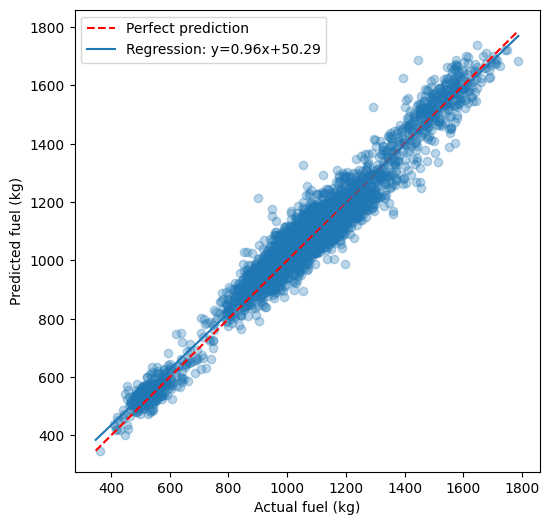

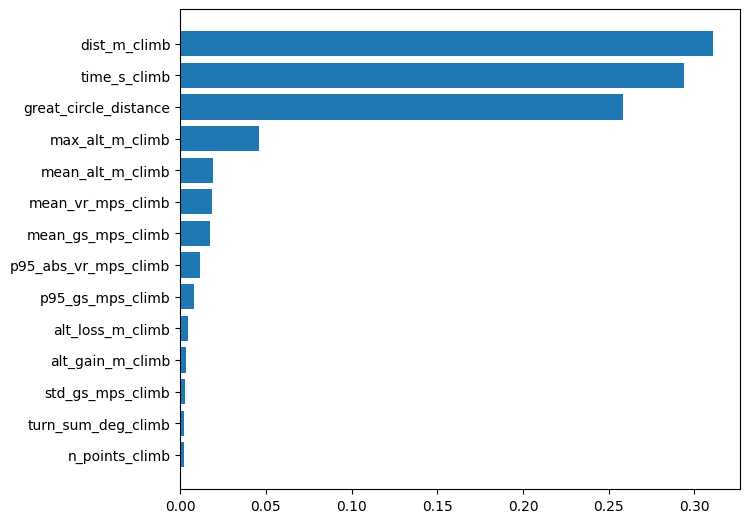

In [20]:
run_regression_report(
    model=final_model,
    X_test=X_test,
    y_test=y_test,
    y_pred=pred_test,
    model_name="Climb model"
)